# Data Acquaintance
A ver Mariano, ahora resulta que este proyecto es tu tesis.  
Lo que pasa es que estoy viendo todos los datos y lo que hice y no me acuerdo de absolutamente nada, así que voy a tener que volver a analizar todo y entender bien de dónde vienen los resultados obtenidos. 

In [1]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString, MultiLineString, Polygon
import warnings

warnings.filterwarnings("ignore")
PATH_DATA = '../data'
# Load unprocessed data
READ_RAW_DATA = False
INICIO_OPERACIONES = pd.to_datetime("2019-04-22")

`2025-08-06`  
No mames Mariano, ya te tardaste un chingo en titularte.  
Siempre que regresas se te olvida qué estás haciendo, así que resumiré:

1. Inferencia causal sobre el efecto de las cámaras de velocidad en el número de incidentes viales en la CDMX
2. Estás utilizando el método de propensity score matching para poder tener grupos de análisis
3. La unidad de tratamiento son áreas cuadradas en la CDMX, para eso tienes todos los datos geoespaciales
4. Para poder calcular la probabilidad de tratamiento, tienes que crear features que permitan hacer el matching de las unidades; para eso tienes los datos del número de incidentes viales, de las cámaras de velocidad. Y utilizarás como proxy del peso de cada una la afluencia del metro más cercano a cada una de las unidades.
5. Ahora que lo pienso, deberías de sentarte a entender cada una de las vialidades y mapear la velocidad máxima en cada una de estas vialiades.

### Leemos los datos

- Los datos de las **cámaras** se pueden encontrar en: `https://datos.cdmx.gob.mx/dataset/fotocivicas`
- Los datos de los **incidentes viales** se pueden encontrar en: `https://datos.cdmx.gob.mx/dataset/incidentes-viales-c5`
  - Resulta que los datos del C5 no son los mejores para analizar los incidentes viales porque depende mucho de la zona en la que estén, así que lo mejor para este caso es utilizar los datos de la SSC, los cuales se pueden encontrar en `https://datos.cdmx.gob.mx/dataset/hechos-de-transito-reportados-por-ssc-base-ampliada-no-comparativa`. Nueva nota: no se usarán los datos del SSC porque no tienen datos de cuando no hubo ningún lesionado.
- Los datos de los **ejes viales** se pueden encontrar en: `https://datos.cdmx.gob.mx/dataset/vialidades-de-la-ciudad-de-mexico`
- Los datos de la **afluencia en el metro** se pueden encontrar en: `https://datos.cdmx.gob.mx/dataset/afluencia-diaria-del-metro-cdmx`

In [2]:
# Datos de las ubicaciones de las cámaras de velocidad
# No se necesita hacer ningún tipo de transformación.
speed_cameras = gpd.read_file(
    os.path.join(
        PATH_DATA,
        'fotocivicas-ubicacion-puntos',
        'fotocivicas-ubicacion-puntos.shp'
    )
)

# Nota para el Mariano del futuro.
# No sé exactamente qué sea esto de speed camera lines
# pero creo que es el área de efectividad de estas, aunque
# no está especificado para todas las cámaras, solo algunas
# Nota del Mariano del futuro
# Sí wey, claramente era eso, pero me imagino que por la 
# complejidad de los datos no se molestaron en calcular
# el área de efectividad para todas
# Nota de otro Mariano del futuro, gracias por las notas anteriores
speed_cameras_lines = gpd.read_file(
    os.path.join(
        PATH_DATA, 
        'fotocivicas-ubicacion-lineas',
        'fotocivicas-ubicacion-lineas.shp'
    )
)

In [3]:
# Datos de los incidentes viales
# Se necesita convertir a parquet porque los datos están pesadísimos en CSV

# También vamos a filtrar solo aquellos datos que sean de tipo A, es decir, Afirmativos
# Según la definición del C5, un incidente de tipo afirmativo es aquel en el cual una
# unidad de atención a emergencias fue despachada, llegó al lugar de los hechos 
# y confirmó la emergencia reportada

# En total, con los datos extraídos el día 30 de marzo del 2025,
# - Había un total de 2_115_080 incidentes en total 
# - Con fechas que iban desde el 31/dic/2013 hasta el 29/feb/2024

# Una vez que nos quedamos con los incidentes de tipo Afirmativos
# - Tenemos en total 866_230 incidentes reales
# - Con fechas en el mismo intervalo de tiempo
if READ_RAW_DATA:
    accidentes = (
        pd
        .read_csv(
            os.path.join(
                PATH_DATA, 
                'raw-data', 
                'inViales_completa.csv'
            )
        )
        .query('codigo_cierre == "A"')
        .query('clas_con_f_alarma not in ("FALSA ALARMA", "INCIDENTES EXTERNOS")')
        .assign(
            timestamp_str=lambda x: x.fecha_creacion + " " + x.hora_creacion,
            timestamp=lambda x: pd.to_datetime(x.timestamp_str, format="%Y-%m-%d %H:%M:%S")
        )
        .astype({
            'tipo_incidente_c4':'category',
            'incidente_c4':'category',
            'clas_con_f_alarma':'category',
        })
        # [[
        #     'folio', 'timestamp', 'tipo_incidente_c4', 
        #     'incidente_c4', 'clas_con_f_alarma', 'latitud', 'longitud'
        # ]]
        .reset_index(drop=True)
        .pipe(
            lambda df: 
            gpd
            .GeoDataFrame(
                data=df.drop(['latitud', 'longitud'], axis=1),
                geometry=gpd.points_from_xy(df.longitud, df.latitud)
            )
        )
    )
else:
    accidentes = (
        pd
        .read_parquet(os.path.join(PATH_DATA, 'incidentes-viales.parquet'))
        .reset_index(drop=True)
        .pipe(
            lambda df: 
            gpd
            .GeoDataFrame(
                data=df.drop(['latitud', 'longitud'], axis=1),
                geometry=gpd.points_from_xy(df.longitud, df.latitud)
            )
        )
    )

In [2]:
# Una de las variables que se usó para asignar las cámaras de velocidad es el flujo de personas
# Dado que esos datos no son de acceso público y de hecho ni siquiera se especifica a qué se refiere con eso
# voy a tener que utilizar un proxy, que será la afluencia de personas de algún tipo
# Lo que voy a usar son las estaciones del metro
# La afluencia total en el año, considerando como ponderador el total de gente en la estación más cercana
# También puede servir como variable la distancia a la primera y segunda estación más cercanas

afluencia = pd.read_csv(os.path.join(PATH_DATA, "raw-data", "afluencia-metro-cdmx.csv"), encoding='utf-8')

# Las coordendas las saqué con google maps (en la compu del trabajo tengo toda la API ya hecha)
# Aquí nada más copié los resultados
coordinates = pd.read_parquet(os.path.join(PATH_DATA, "metro-station-coordinates.parquet"))

In [6]:
afluencia_mensual = (
    afluencia
    .assign(
        fecha=lambda x: pd.to_datetime(x.fecha, errors='coerce')
    )
    .dropna()
    .groupby([
        pd.Grouper(key='fecha', freq='m', ),
        'estacion'
    ])
    .agg(
        afluencia_total=pd.NamedAgg('afluencia', 'sum'), # suma de la afluencia diaria
        media_diaria=pd.NamedAgg('afluencia', 'mean'),
        std_diaria=pd.NamedAgg('afluencia', 'std')
    )
    .reset_index()
    .assign(
        before_treatment=lambda x: x.fecha.apply(lambda f: f < INICIO_OPERACIONES)
    )
)
afluencia_mensual.to_parquet(os.path.join(PATH_DATA, "afluencia-metro-mensual.parquet"), index=False)

In [12]:
# Ahora hay que hacer afluencia semanal
afluencia_semanal = (
    afluencia
    .assign(
        fecha=lambda x: pd.to_datetime(x.fecha, errors='coerce')
    )
    .dropna()
    .groupby([
        pd.Grouper(key="fecha", freq="1W"),
        pd.Grouper(key="estacion")
    ])
    .agg(
        afluencia_total=pd.NamedAgg("afluencia", "sum"),
        media_diaria=pd.NamedAgg('afluencia', 'mean'),
        std_diaria=pd.NamedAgg('afluencia', 'std')
    )
    .reset_index()
    .assign(
        before_treatment=lambda x: x.fecha.apply(lambda f: f < INICIO_OPERACIONES)
    )
)
afluencia_semanal.to_parquet(os.path.join(PATH_DATA, "afluencia-metro-semanal.parquet"), index=False)

In [7]:
# Datos de las vialidades principales
# Este es el único al que no hay que hacerle nada
# Solo considerar que el único que funciona es el GeoJson
# Porque el otro está en otras coordenadas
vialidades = gpd.read_file(os.path.join(PATH_DATA, 'vialidades.json'))

In [8]:
radares = gpd.read_file(os.path.join(PATH_DATA, 'radares_fotocivicas.gpkg'))

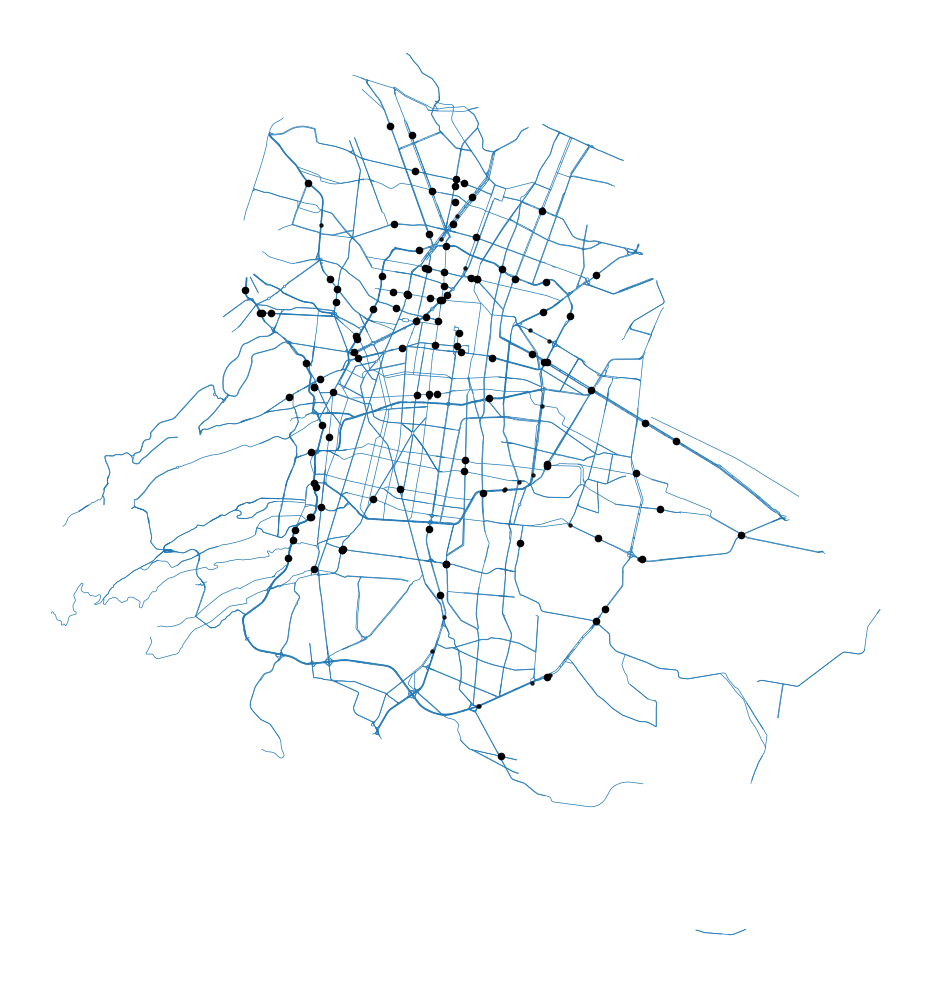

In [97]:
fig, ax = plt.subplots(figsize=(10,10))
ax.axis('off')
speed_cameras.plot(ax=ax, color='black', markersize=20)
(
    radares
    .dropna(subset=['x'])
    .query('anio == 2024 and tipo == "radar fijo"')
    .plot(ax=ax, markersize=5, alpha=.8, color='black')
)
vialidades.plot(ax=ax, linewidth=.5, zorder=-1)
fig.tight_layout()
fig.savefig(os.path.join(PATH_DATA, "graphs", "general-map-of-radars.png"), dpi=300, transparent=True)

### Volumen de tránsito
Resula que sí existe información del volumen de tránsito en los radares permanentes, solo que está en un formato asqueroso: pdf.
- Se extraen los pdfs correspondientes a cada año desde 2015 hasta 2024
- Se identifican los radares que están en la ciudad de méxico
- Se extrae la información de cada una de ellas utiizando ChatGPT (sino sería una hueva sacar todo a mano)

In [50]:
volumen = pd.read_excel(
    os.path.join(PATH_DATA, "raw-data", "volumen-tránsito.xlsx"),
    sheet_name="volumen"
)

indicadores = pd.read_excel(
    os.path.join(PATH_DATA, "raw-data", "volumen-tránsito.xlsx"),
    sheet_name="indicadores"
)

In [52]:
# estoy seguro de que en algún momento se me va a olvidar qué chingados es esto
# el tema es que los radares son permanentes, pero conforme van aumentando la cantidad, mueven su ID (indicador)
# entonces, el mismo radar puede tener un indicador distinto en distintos años
# Lo que sí se mantiene igual en todos los años es: carretera, movimiento, caseta, kilómetro
# con eso podemos sacar la equivalencia en cada uno de los años
# esta tabla funciona más como referencia que nada más
save = False
equivalencias_indicadores = (
    volumen
    .merge(
        indicadores,
        on=["indicador", "year"],
        how="inner"
    )
    .pivot(
        index=["carretera", "movimiento", "caseta", "kilometro"],
        columns="year",
        values="indicador"
    )
)
if save:
    equivalencias_indicadores.reset_index().to_csv(os.path.join(PATH_DATA, "equivalencia-indicadores-permanentes-volumen.csv"), index=False)
    
# Una vez que ya tenemos todos los indicadores desde 2015 hasta 2024, nos vamos a quedar solo con aquellos que sí 
# hayan estado presentes durante toda la duración del estudio, porque sino estaríamos metiendo ruido innecesario
indicadores_finales = (
    equivalencias_indicadores
    .pipe(lambda df: df[df.isna().astype(int).sum(axis=1) == 0])
    .melt(ignore_index=False, value_name='indicador')
    .reset_index()
    .merge(volumen, on=["indicador", "year"], how="inner")
    .drop_duplicates(subset=["carretera", "movimiento", "caseta", "kilometro", "indicador", "year"])
    [["carretera", "movimiento", "caseta", "kilometro", "indicador", "year", "lat", "long"]]
)

if save:
    indicadores_finales.to_csv(os.path.join(PATH_DATA, "indicadores-volumen-transito-finales.csv"), index=False)
    
final_volumen_anual = (
    volumen
    .drop(columns=["lat", "long"])
    .merge(indicadores_finales[["indicador", "year"]], on=["indicador", "year"])
    .melt(id_vars=["indicador", "year", "volumen_total_anual"], value_name="porcentaje", var_name="month")
)

if save:
    final_volumen_anual.to_csv(os.path.join(PATH_DATA, "volumen-anual-total-radares.csv"), index=False)